# Traffic Sign Recognition — Model Training & Evaluation Metrics
### Role: Classification using SVM vs CNN



---
## 1. Install & Import Libraries

In [1]:
#!pip install scikit-learn pandas numpy matplotlib seaborn tensorflow -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Conv1D, Flatten, MaxPooling1D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'   TensorFlow version : {tf.__version__}')

   TensorFlow version : 2.19.0


---
## 2. Load Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/features.csv'

df = pd.read_csv(CSV_PATH)
print(f'Dataset loaded  →  {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Mounted at /content/drive
Dataset loaded  →  14620 rows, 2280 columns


,image_path,split,f0,f1,f2,f3,f4,f5,f6,f7,...,f2268,f2269,f2270,f2271,f2272,f2273,f2274,f2275,f2276,label
0,processed_dataset\train/0/00000_00000_00000.png,train,0.0,0.000000,0.089217,0.091505,0.043465,0.050328,0.020589,0.013726,...,0.289191,0.078332,0.029459,0.014006,0.110665,0.000000,0.111046,0.120304,0.289191,0
1,processed_dataset\train/0/00000_00000_00000_au...,train,0.0,0.057357,0.116919,0.105889,0.057357,0.035296,0.037502,0.017648,...,0.196349,0.302734,0.217799,0.302734,0.302734,0.030492,0.012914,0.005245,0.000000,0
2,processed_dataset\train/0/00000_00000_00002.png,train,0.0,0.139988,0.339643,0.174411,0.061962,0.013769,0.011474,0.022949,...,0.291922,0.110760,0.157910,0.065926,0.193110,0.017965,0.111195,0.091873,0.287196,0
3,processed_dataset\train/0/00000_00000_00002_au...,train,0.0,0.105489,0.127382,0.029855,0.025875,0.005971,0.021894,0.007961,...,0.138256,0.034263,0.023968,0.000000,0.069308,0.000000,0.000000,0.353214,0.155663,0
4,processed_dataset\train/0/00000_00000_00003.png,train,0.0,0.058583,0.199181,0.096075,0.051553,0.025776,0.009373,0.011717,...,0.245391,0.005791,0.000000,0.000000,0.091210,0.000000,0.007761,0.219881,0.290340,0


---
## 3. Data Preparing

In [5]:
#Identify columns
LABEL_COL      = 'label'
IMAGE_PATH_COL = 'image_path'

# Drop ALL non-numeric columns from features
non_feature_cols = [LABEL_COL, IMAGE_PATH_COL]

# Also drop any other string/object columns automatically
object_cols = df.select_dtypes(include=['object']).columns.tolist()
non_feature_cols = list(set(non_feature_cols + object_cols))

feature_cols = [c for c in df.columns if c not in non_feature_cols]

print('Dropped columns (non-numeric):', non_feature_cols)
print('Feature columns kept         :', len(feature_cols))

X = df[feature_cols].values.astype(np.float32)
y_raw = df[LABEL_COL].values
image_paths = df[IMAGE_PATH_COL].values if IMAGE_PATH_COL in df.columns else np.arange(len(df)).astype(str)

print(f'\nFeature matrix shape : {X.shape}')
print(f'Labels               : {np.unique(y_raw)}')
print(f'Number of classes    : {len(np.unique(y_raw))}')

Dropped columns (non-numeric): ['image_path', 'split', 'label']
Feature columns kept         : 2277

Feature matrix shape : (14620, 2277)
Labels               : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Number of classes    : 43


- Encode labels and class distribution plot

Label mapping:
    0  →  0
    1  →  1
    2  →  2
    3  →  3
    4  →  4
    5  →  5
    6  →  6
    7  →  7
    8  →  8
    9  →  9
   10  →  10
   11  →  11
   12  →  12
   13  →  13
   14  →  14
   15  →  15
   16  →  16
   17  →  17
   18  →  18
   19  →  19
   20  →  20
   21  →  21
   22  →  22
   23  →  23
   24  →  24
   25  →  25
   26  →  26
   27  →  27
   28  →  28
   29  →  29
   30  →  30
   31  →  31
   32  →  32
   33  →  33
   34  →  34
   35  →  35
   36  →  36
   37  →  37
   38  →  38
   39  →  39
   40  →  40
   41  →  41
   42  →  42


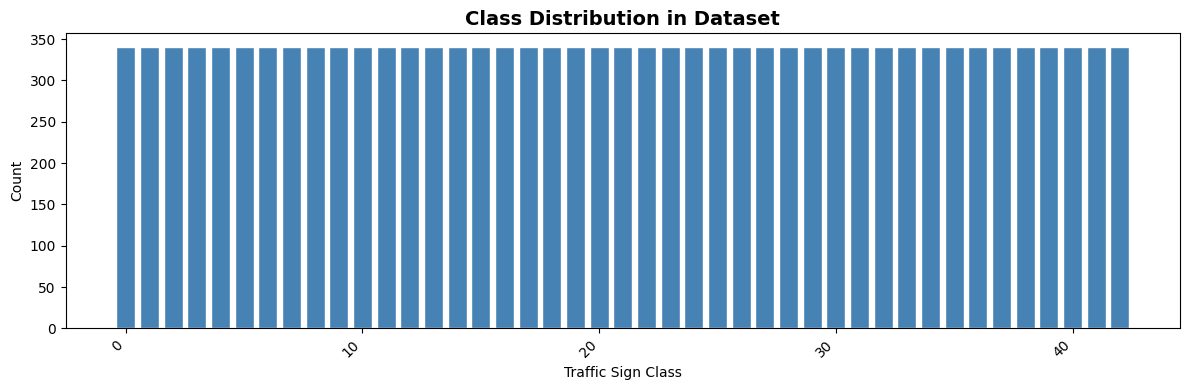

In [6]:
#Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)

print('Label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:3d}  →  {cls}')

#Class distribution plot
fig, ax = plt.subplots(figsize=(12, 4))
unique, counts = np.unique(y_raw, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Sign Class')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Train / Test Split

In [7]:
TEST_SIZE = 0.20
RANDOM_STATE = 42

(
    X_train, X_test,
    y_train, y_test,
    paths_train, paths_test
) = train_test_split(
    X, y, image_paths,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')

Train samples : 11696
Test  samples : 2924


---
## 5. Features Normalization

In [8]:
#Fill any NaN values before scaling
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features normalized (StandardScaler)')
print(f'   Mean (train) : {X_train_scaled.mean():.4f}  (should be ≈ 0)')
print(f'   Std  (train) : {X_train_scaled.std():.4f}   (should be ≈ 1)')

Features normalized (StandardScaler)
   Mean (train) : -0.0000  (should be ≈ 0)
   Std  (train) : 0.9918   (should be ≈ 1)


---
## 6. SVM Model

In [9]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_scaled, y_train)

svm_preds = svm_model.predict(X_test_scaled)

svm_acc  = accuracy_score(y_test, svm_preds)
svm_prec = precision_score(y_test, svm_preds, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test, svm_preds, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test, svm_preds, average='weighted', zero_division=0)

- SVM Results ans classification report

In [10]:
print(f'\nSVM Results:')
print(f'   Accuracy  : {svm_acc:.4f}')
print(f'   Precision : {svm_prec:.4f}')
print(f'   Recall    : {svm_rec:.4f}')
print(f'   F1 Score  : {svm_f1:.4f}')
print('Classification Report:')
print(classification_report(y_test, svm_preds, target_names=[str(cls) for cls in le.classes_]))


SVM Results:
   Accuracy  : 0.9104
   Precision : 0.9175
   Recall    : 0.9104
   F1 Score  : 0.9122
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        68
           1       0.91      0.87      0.89        68
           2       0.75      0.75      0.75        68
           3       0.78      0.91      0.84        68
           4       0.92      0.90      0.91        68
           5       0.86      0.75      0.80        68
           6       1.00      0.96      0.98        68
           7       0.95      0.85      0.90        68
           8       0.84      0.90      0.87        68
           9       0.97      0.93      0.95        68
          10       0.95      0.90      0.92        68
          11       0.81      0.90      0.85        68
          12       0.55      0.90      0.68        68
          13       0.94      0.93      0.93        68
          14       0.99      0.99      0.99        68
          

- SVM Confusion Matrix

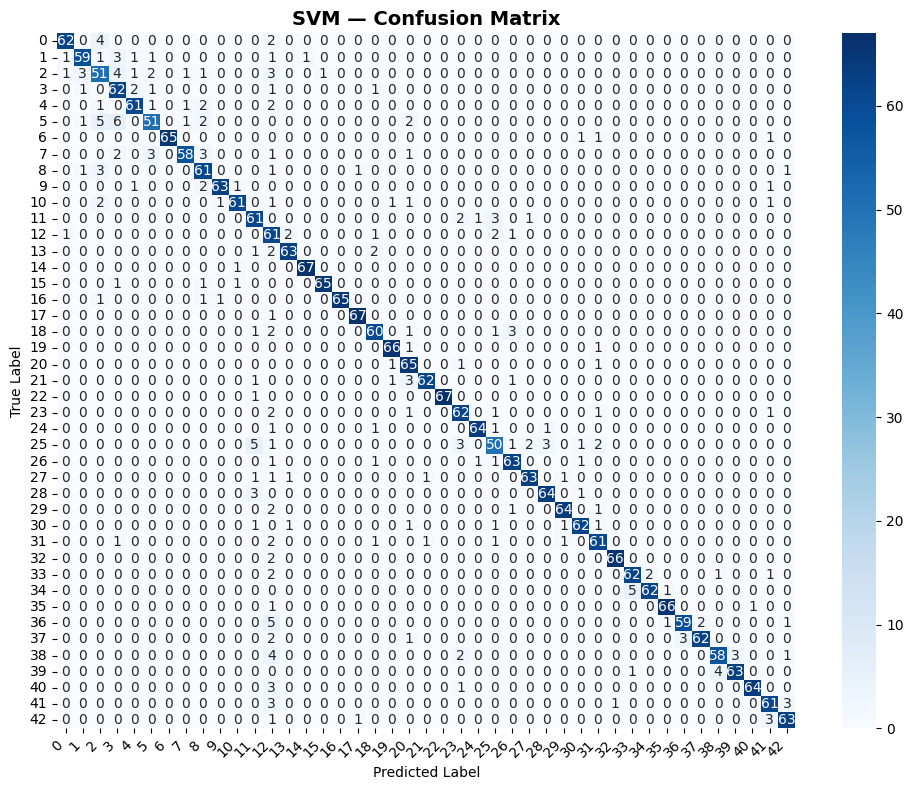

In [11]:
cm_svm = confusion_matrix(y_test, svm_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('SVM — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. CNN Model

In [12]:
#Prepare CNN input (needs 3D shape for Conv1D: samples, timesteps, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

INPUT_SHAPE = (X_train_cnn.shape[1], 1)
print(f'CNN input shape : {INPUT_SHAPE}')
print(f'Output classes  : {NUM_CLASSES}')

CNN input shape : (2277, 1)
Output classes  : 43


- Build CNN architecture

In [13]:
def build_cnn(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 2
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.25),

        # Classifier head
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2277, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2277, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1138, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1138, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1138, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1138, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 569, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 569, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 569, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 569, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 569, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 145664)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    37,290,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,455,019 (142.88 MB)

 Trainable params: 37,453,611 (142.87 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

#Train CNN
print('Training CNN ...')
history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.15,
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Training CNN ...
Epoch 1/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.4148 - loss: 2.1994 - val_accuracy: 0.4536 - val_loss: 1.7921 - learning_rate: 0.0010
Epoch 2/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6959 - loss: 1.0309 - val_accuracy: 0.8296 - val_loss: 0.6012 - learning_rate: 0.0010
Epoch 3/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8030 - loss: 0.6399 - val_accuracy: 0.8604 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 4/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8670 - loss: 0.4318 - val_accuracy: 0.8781 - val_loss: 0.4317 - learning_rate: 0.0010
Epoch 5/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9061 - loss: 0.3013 - val_accuracy: 0.8877 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 6/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9295 - loss: 0.2186 - val_accuracy: 0.8923 - val_loss: 0.4204 - learning_rate: 0.0010
Epoch 7/60
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy:

- CNN Training Curves

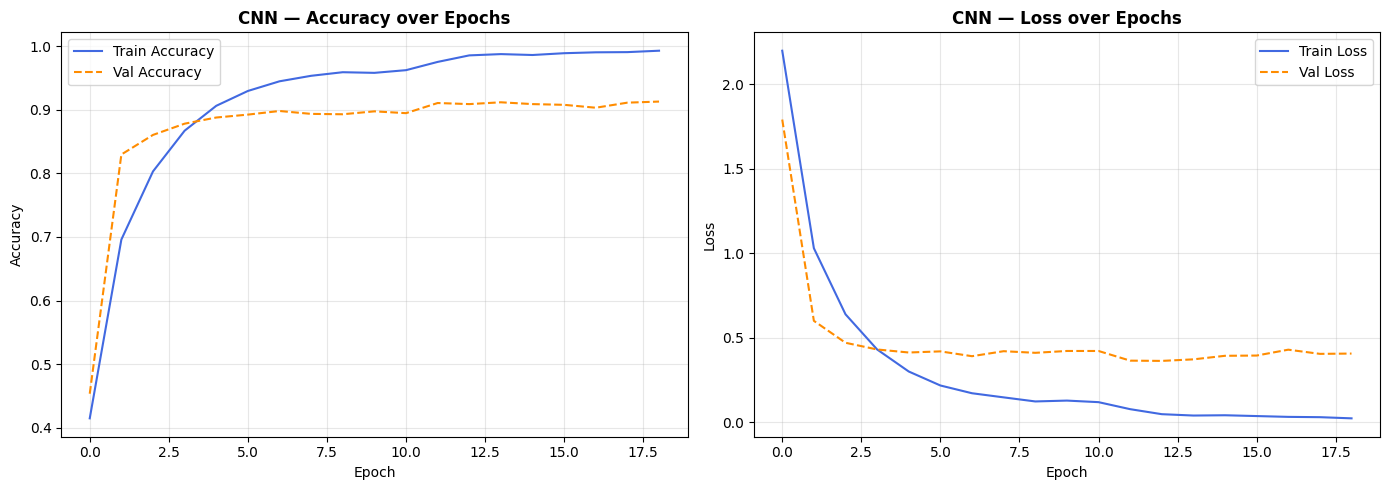

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[0].set_title('CNN — Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorange', linestyle='--')
axes[1].set_title('CNN — Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- CNN Evaluation

In [16]:
cnn_preds_prob = cnn_model.predict(X_test_cnn)
cnn_preds = np.argmax(cnn_preds_prob, axis=1)

cnn_acc  = accuracy_score(y_test, cnn_preds)
cnn_prec = precision_score(y_test, cnn_preds, average='weighted', zero_division=0)
cnn_rec  = recall_score(y_test, cnn_preds, average='weighted', zero_division=0)
cnn_f1   = f1_score(y_test, cnn_preds, average='weighted', zero_division=0)

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


- CNN Results and classification Report

In [17]:
print('CNN Results:')
print(f'   Accuracy  : {cnn_acc:.4f}')
print(f'   Precision : {cnn_prec:.4f}')
print(f'   Recall    : {cnn_rec:.4f}')
print(f'   F1 Score  : {cnn_f1:.4f}')

print('CNN — Full Classification Report:')
print(classification_report(y_test, cnn_preds, target_names=[str(cls) for cls in le.classes_]))

CNN Results:
   Accuracy  : 0.9097
   Precision : 0.9116
   Recall    : 0.9097
   F1 Score  : 0.9094
CNN — Full Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        68
           1       0.84      0.87      0.86        68
           2       0.81      0.71      0.76        68
           3       0.87      0.85      0.86        68
           4       0.86      0.87      0.86        68
           5       0.77      0.85      0.81        68
           6       0.98      0.96      0.97        68
           7       0.79      0.88      0.83        68
           8       0.79      0.82      0.81        68
           9       0.89      0.91      0.90        68
          10       0.84      0.84      0.84        68
          11       0.93      0.84      0.88        68
          12       0.95      0.87      0.91        68
          13       0.98      0.91      0.95        68
          14       0.99      0.97      0.98        68


- CNN Confusion Matrix

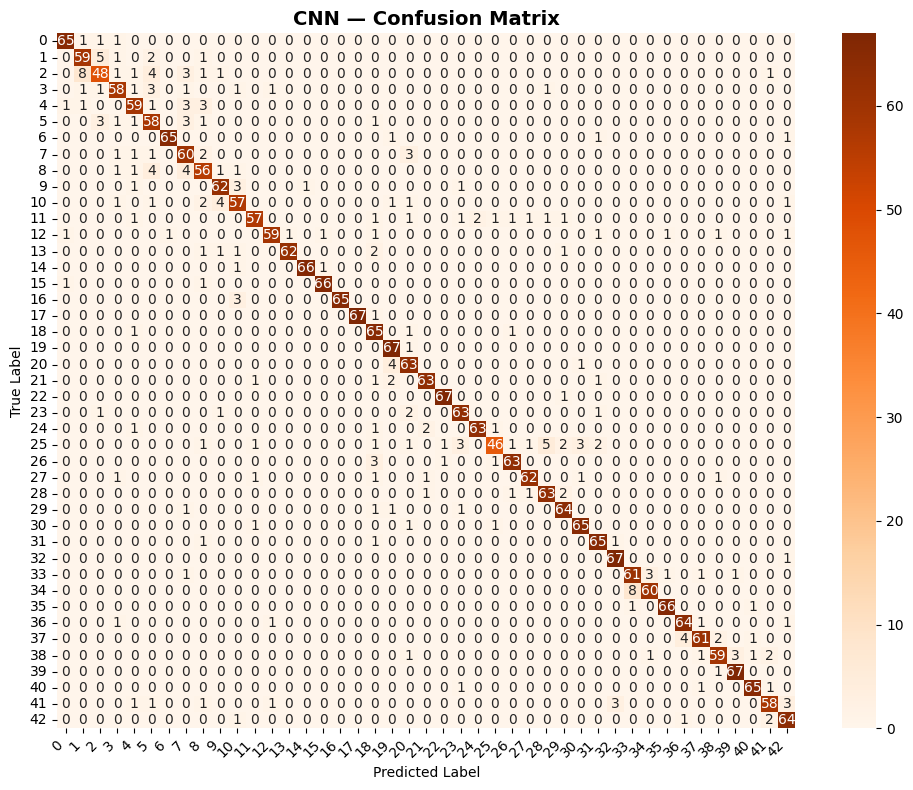

In [18]:
cm_cnn = confusion_matrix(y_test, cnn_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('CNN — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8. SVM vs CNN Comparison

- Comparison Table

In [19]:
comparison = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'SVM'      : [svm_acc,  svm_prec,  svm_rec,  svm_f1],
    'CNN'      : [cnn_acc,  cnn_prec,  cnn_rec,  cnn_f1],
})
comparison['Best Model'] = comparison.apply(
    lambda row: 'SVM' if row['SVM'] > row['CNN'] else 'CNN', axis=1
)
comparison[['SVM','CNN']] = comparison[['SVM','CNN']].round(4)

print('\n' + '='*55)
print('         SVM  vs  CNN  —  Performance Summary')
print('='*55)
print(comparison.to_string(index=False))
print('='*55)

         SVM  vs  CNN  —  Performance Summary


- Grouped Bar Chart

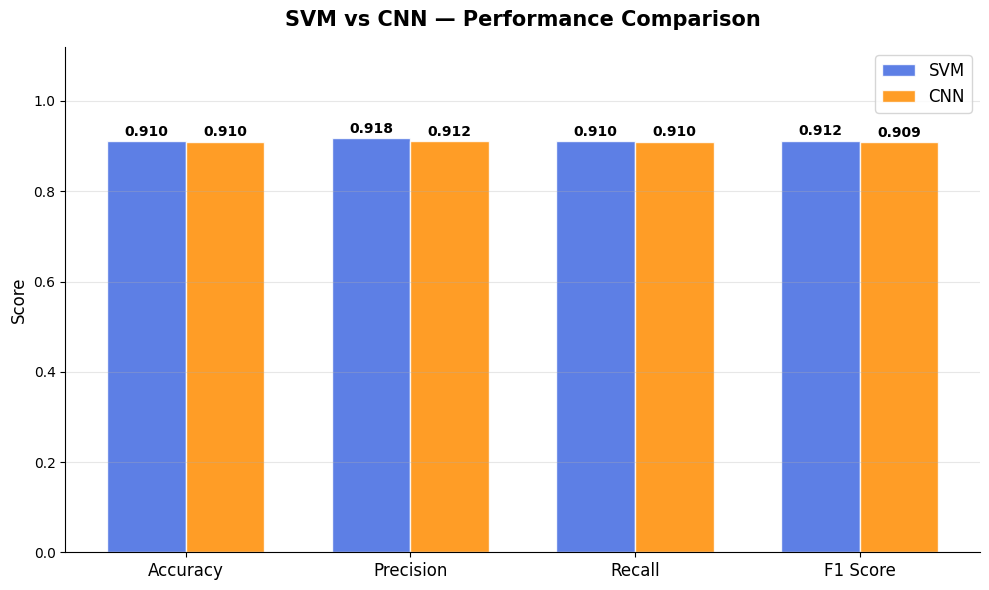

In [20]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1]
cnn_vals = [cnn_acc, cnn_prec, cnn_rec, cnn_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, svm_vals, width, label='SVM', color='royalblue',    alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, cnn_vals, width, label='CNN', color='darkorange', alpha=0.85, edgecolor='white')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('SVM vs CNN — Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

- Side-by-side Confusion Matrices

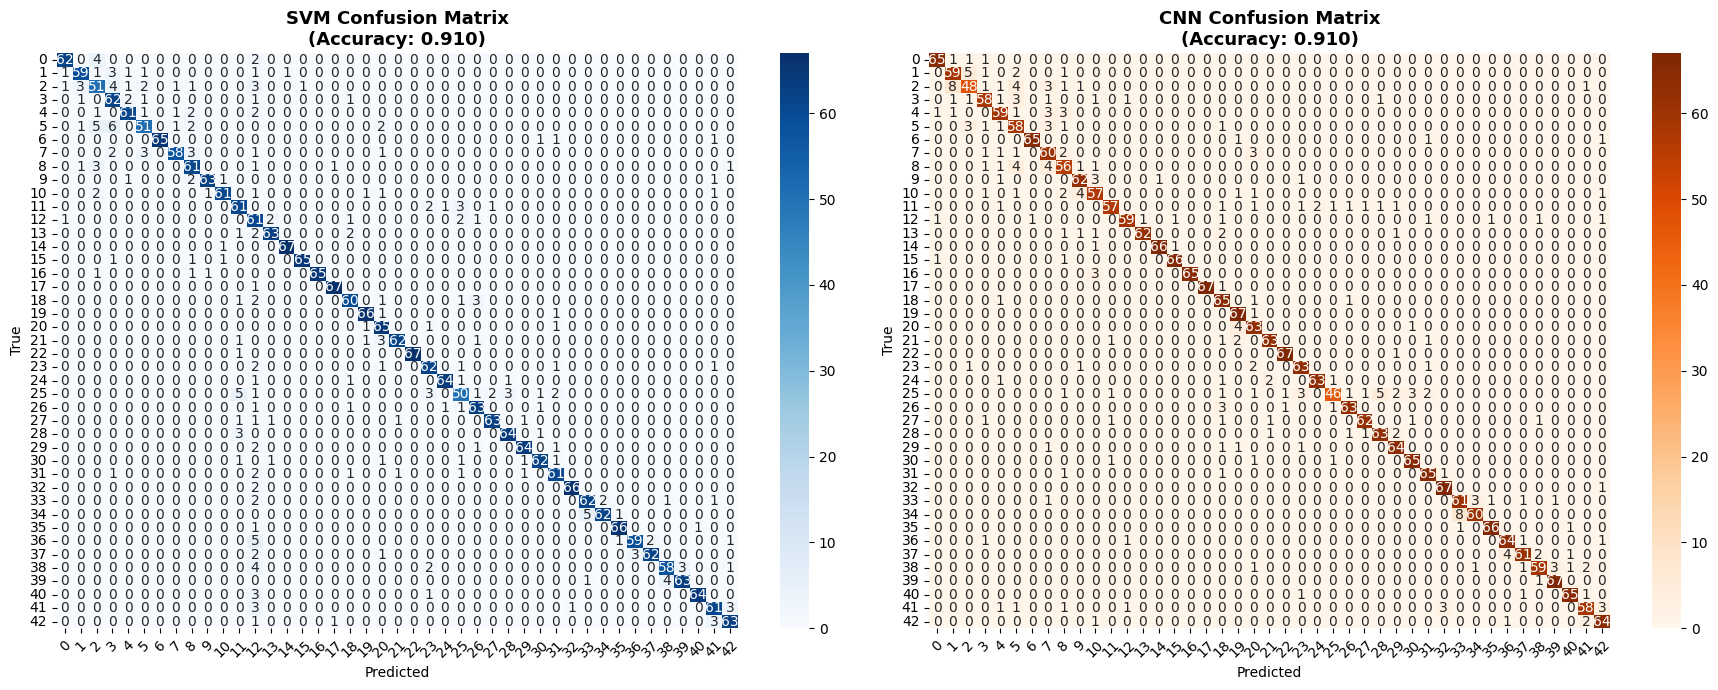

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'SVM Confusion Matrix\n(Accuracy: {svm_acc:.3f})', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'CNN Confusion Matrix\n(Accuracy: {cnn_acc:.3f})', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Final Verdict

In [22]:
best = 'CNN' if cnn_acc >= svm_acc else 'SVM'
diff = abs(cnn_acc - svm_acc) * 100
print('\n' + '='*55)
print(f'  Best model  →  {best}')
print(f'  Accuracy difference  →  {diff:.2f}%')
print('='*55)
print('\nConclusion:')
if cnn_acc > svm_acc:
    print(f'  CNN outperforms SVM by {diff:.2f}% accuracy.')
    print('  CNN captures non-linear patterns better from feature vectors.')
elif svm_acc > cnn_acc:
    print(f'  SVM outperforms CNN by {diff:.2f}% accuracy.')
    print('  SVM generalizes better on this feature set (possibly small dataset).')
else:
    print('  Both models perform equally. Consider other factors (speed, size).')


  Best model  →  SVM
  Accuracy difference  →  0.07%

Conclusion:
  SVM outperforms CNN by 0.07% accuracy.
  SVM generalizes better on this feature set (possibly small dataset).


---
## 9. Save Outputs

In [23]:
true_labels_str   = le.inverse_transform(y_test)
svm_labels_str    = le.inverse_transform(svm_preds)
cnn_labels_str    = le.inverse_transform(cnn_preds)

predictions_df = pd.DataFrame({
    'image_path'        : paths_test,
    'true_label'        : true_labels_str,
    'predicted_label_svm': svm_labels_str,
    'predicted_label_cnn': cnn_labels_str,
    'svm_correct'       : (svm_labels_str == true_labels_str),
    'cnn_correct'       : (cnn_labels_str == true_labels_str),
})

predictions_df.to_csv('predictions.csv', index=False)
print('predictions.csv saved')
predictions_df.head(10)

predictions.csv saved


,image_path,true_label,predicted_label_svm,predicted_label_cnn,svm_correct,cnn_correct
0,processed_dataset\train/38/00038_00050_00022.png,38,12,34,False,False
1,processed_dataset\train/16/00016_00003_00001.png,16,16,16,True,True
2,processed_dataset\train/24/00024_00002_00029.png,24,24,24,True,True
3,processed_dataset\val/33/00033_00008_00015.png,33,33,33,True,True
4,processed_dataset\train/24/00024_00006_00009_a...,24,24,24,True,True
5,processed_dataset\test/40/00040_00008_00009.png,40,40,40,True,True
6,processed_dataset\train/37/00037_00003_00003_a...,37,20,37,False,True
7,processed_dataset\train/6/00006_00007_00016_au...,6,6,6,True,True
8,processed_dataset\test/13/00013_00031_00027.png,13,13,13,True,True
9,processed_dataset\train/34/00034_00001_00002_a...,34,34,34,True,True


In [24]:
joblib.dump(svm_model, 'svm_trained_model.pkl')
joblib.dump(scaler,    'feature_scaler.pkl')
joblib.dump(le,        'label_encoder.pkl')
print(' SVM model saved  →  svm_trained_model.pkl')
print('Scaler saved     →  feature_scaler.pkl')
print('Encoder saved    →  label_encoder.pkl')


cnn_model.save('cnn_trained_model.keras')
print('CNN model saved  →  cnn_trained_model.keras')

 SVM model saved  →  svm_trained_model.pkl
Scaler saved     →  feature_scaler.pkl
Encoder saved    →  label_encoder.pkl
CNN model saved  →  cnn_trained_model.keras


In [25]:
from google.colab import files

files.download('predictions.csv')
files.download('svm_trained_model.pkl')
files.download('feature_scaler.pkl')
files.download('label_encoder.pkl')
files.download('cnn_trained_model.keras')

print('\n All files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All files downloaded!
